# Week 8 – Why Do Neural Networks Work?

## 1. Introduction
- Historical context: Hilbert’s 13th problem → the Kolmogorov–Arnold representation theorem  
- Goal: to develop a mathematical understanding of neural networks as function approximators  
- Connections: approximation theory, functional analysis

## 2. From the Previous Lecture: The Perceptron (Continued)

### Model
We consider binary classification with labels $y \in \{-1, +1\}$ and inputs $x \in \mathbb{R}^d$.

The perceptron defines a linear classifier:
$$
f(x) = \operatorname{sign}(w \cdot x + b),
$$
where $w \in \mathbb{R}^d$ and $b \in \mathbb{R}$.

By augmenting the input as $\tilde{x} = (x,1)$ and parameter $\tilde{w} = (w,b)$, we can write:
$$
f(x) = \operatorname{sign}(\tilde{w} \cdot \tilde{x}).
$$

<center>
  <img src="./perceptron.png" width="450">
</center>

**Geometric interpretation:**  
The decision boundary is the hyperplane
$$
\{x \in \mathbb{R}^d : w \cdot x + b = 0\},
$$
which separates the space into two half-spaces.

**Learning Algorithm:**

Given a dataset $\{(x_i, y_i)\}_{i=1}^N$, the algorithm iteratively updates the weights.

Initialize $w_0 = 0$. For each misclassified point $(x_i, y_i)$:
$$
w_{k+1} = w_k + y_i x_i.
$$

Equivalently, update only if:
$$
y_i (w_k \cdot x_i) \leq 0.
$$

#### Perceptron vs. Support Vector Machine (SVM)

Both the **Perceptron** and the **Support Vector Machine (SVM)** learn a linear decision function.

Thus:
- both construct a **separating hyperplane**,
- both are **linear classifiers** in the input space,
- both admit nonlinear extensions (via feature maps or kernels).

>**The Crucial Difference: What Is Being Optimized?**

**Perceptron**
- No explicit global objective
- Online update on misclassified samples:
- Goal: find **any separating hyperplane**

**SVM**
- Solves a **convex optimization problem**:
$$
\min_{w,b} \frac{1}{2}\|w\|^2 + C \sum_i \xi_i
$$
- Goal: **maximum margin classifier**
- Allows classification errors (soft margin)

👉 Core distinction:
- **Perceptron** → feasibility  
- **SVM** → optimality + regularization

##### Further differences

**(a) Uniqueness of model parameters**
- Perceptron: depends on data order  
- SVM: unique global optimum

**(b) Generalization**
- Perceptron: no explicit control  
- SVM: margin maximization → strong generalization guarantees

**(c) Non-separable Data**
- Perceptron: may not converge  
- SVM: handles via slack variables

**(d) Sparsity**
- Perceptron: many points influence solution  
- SVM: only **support vectors** matter

**(e) Kernelization**
- Perceptron: kernel extension exists (algorithmic trick)  
- SVM: kernelization is **intrinsic** (via duality theory)

#### Limitations of the Perceptron Model

- Linear separation (using a hyperplane / straight line) provides only a very limited representational capacity and learning ability in practice.
- Unfortunately, only a small subset of real-world problems can be solved in such a simple way.
- For example, the logical AND and OR functions can be learned, but XOR cannot be represented by a single linear separator.
- This limitation was formally pointed out by Minsky and Papert in 1969.
- As a consequence, research on neural models was largely neglected until the 1980s.
- This period is often referred to as the first "AI winter".

### Convergence Theorem (Perceptron)

**Theorem:** Assume that there exists $w^* \in \mathbb{R}^d$ such that
$$
y_i (w^* \cdot x_i) \geq \gamma > 0 \quad \text{for all } i,
$$
for some margin $\gamma$. Suppose also $\|x_i\| \leq R$ for all $i$.

Then the perceptron algorithm makes at most
$$
\frac{R^2 \|w^*\|^2}{\gamma^2}
$$
updates. In particular, it converges in finitely many steps.

**Proof**

Let $w_k$ denote the weight after $k$ updates.

**Step 1:** Growth of alignment

If $(x_i,y_i)$ is misclassified at step $k$, then:
$$
w_{k+1} = w_k + y_i x_i.
$$

Taking inner product with $w^*$:
$$
w_{k+1} \cdot w^* = w_k \cdot w^* + y_i (x_i \cdot w^*).
$$

By separability:
$$
y_i (x_i \cdot w^*) \geq \gamma,
$$
hence
$$
w_{k+1} \cdot w^* \geq w_k \cdot w^* + \gamma.
$$

Iterating:
$$
w_k \cdot w^* \geq k \gamma.
$$

**Step 2:** Growth of norm

We estimate $\|w_k\|^2$.

$$
\|w_{k+1}\|^2 = \|w_k + y_i x_i\|^2
= \|w_k\|^2 + 2 y_i (w_k \cdot x_i) + \|x_i\|^2.
$$

Since $(x_i,y_i)$ is misclassified:
$$
y_i (w_k \cdot x_i) \leq 0,
$$
thus
$$
\|w_{k+1}\|^2 \leq \|w_k\|^2 + \|x_i\|^2 \leq \|w_k\|^2 + R^2.
$$

By induction:
$$
\|w_k\|^2 \leq k R^2.
$$

**Step 3:** Combine bounds

Using Cauchy–Schwarz:
$$
w_k \cdot w^* \leq \|w_k\| \|w^*\|.
$$

Thus:
$$
k \gamma \leq \|w_k\| \|w^*\| \leq \sqrt{k} R \|w^*\|.
$$

Divide by $\sqrt{k}$:
$$
\sqrt{k} \gamma \leq R \|w^*\|.
$$

Hence:
$$
k \leq \frac{R^2 \|w^*\|^2}{\gamma^2}.
$$

## Perceptron Convergence Demonstration

This experiment illustrates the convergence behavior of the perceptron learning algorithm on a linearly separable dataset.

**Setup**

- We generate two clusters in $\mathbb{R}^2$:
  - Positive class centered around $(2,2)$
  - Negative class centered around $(-2,-2)$
- Labels: $y \in \{-1, +1\}$

By construction, the dataset is linearly separable. Then we apply the classical perceptron update rule.

**What is being tracked?**

- Number of updates until convergence
- Sequence of decision boundaries during training
- Final separating hyperplane

The plot shows:
- Data points from both classes
- Intermediate decision boundaries (faint lines)
- Final decision boundary (highlighted)

**Expected Behavior**
- Since the data is linearly separable, the perceptron converges in finitely many steps
- The separating hyperplane stabilizes after a finite number of updates
- The number of updates depends on:
  - the margin $\gamma$
  - the data radius $R$
    
Interpretation:
- Each update moves the decision boundary toward correct classification
- The algorithm implicitly searches for a separating hyperplane
- Convergence reflects the classical perceptron theorem:
  $$
  k \leq \frac{R^2 \|w^*\|^2}{\gamma^2}
  $$

Number of updates: 52


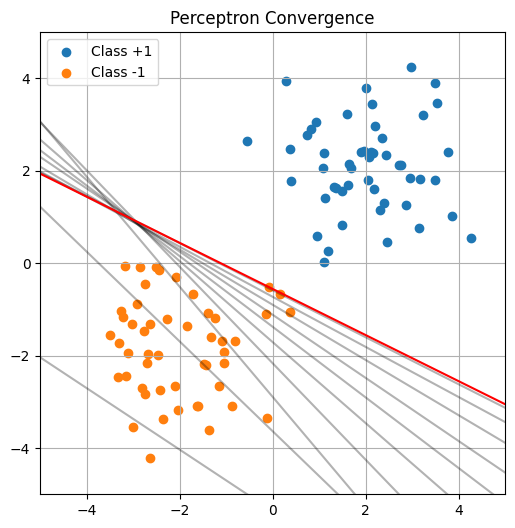

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- Generate linearly separable data ---
np.random.seed(0)

N = 100
X_pos = np.random.randn(N//2, 2) + np.array([2, 2])
X_neg = np.random.randn(N//2, 2) + np.array([-2, -2])

X = np.vstack([X_pos, X_neg])
y = np.hstack([np.ones(N//2), -np.ones(N//2)])

# --- Perceptron ---
w = np.array([0,5])
b = 80

max_iters = 1000
updates = 0

history = []

for _ in range(max_iters):
    error = False
    for i in range(N):
        if y[i] * (np.dot(w, X[i]) + b) <= 0:
            w = w + y[i] * X[i]
            b = b + y[i]
            updates += 1
            error = True
            history.append((w.copy(), b))
    if not error:
        break

print(f"Number of updates: {updates}")

# --- Plot decision boundary evolution ---
def plot_boundary(w, b, color='k', alpha=1):
    x_vals = np.linspace(-5, 5, 100)
    if w[1] != 0:
        y_vals = -(w[0]*x_vals + b) / w[1]
        plt.plot(x_vals, y_vals, color=color, alpha=alpha)

plt.figure(figsize=(6,6))

plt.scatter(X_pos[:,0], X_pos[:,1], label="Class +1")
plt.scatter(X_neg[:,0], X_neg[:,1], label="Class -1")

# initial boundary
plot_boundary(np.zeros(2), 0, color='gray', alpha=0.3)

# intermediate boundaries
for w_i, b_i in history[::max(1, len(history)//10)]:
    plot_boundary(w_i, b_i, alpha=0.3)

# final boundary
plot_boundary(w, b, color='red', alpha=1)

plt.legend()
plt.title("Perceptron Convergence")
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.grid()
plt.show()

## 3. Universal Approximation Results

This section collects foundational results showing that neural networks are dense in spaces of continuous functions.

## Hilbert’s 13th Problem and its Connection to the Kolmogorov–Arnold Theorem

<center>
 <img src="./Hilbert.jpeg" width="200">
  <img src="./Kolmogorov.jpg" width="200">
  <img src="./Arnold.jpg" width="200">
</center>

- In 1900, at the International Congress of Mathematicians in Paris, David Hilbert presented his famous list of 23 open problems, which profoundly shaped the development of 20th-century mathematics.
- These problems were intended as guiding challenges for future research across multiple areas of mathematics, including analysis, algebra, geometry, and mathematical physics.

### Hilbert’s 13th Problem

- The 13th problem concerns the structure of solutions to algebraic equations and their representability in terms of functions of fewer variables. 
- More precisely, Hilbert asked whether the general solution of the seventh-degree algebraic equation can be expressed as a composition of continuous functions of two variables.

At its core, the problem reflects a deeper question about the complexity of multivariate functions: 
>can functions of several variables be reduced, via superposition, to functions of fewer variables?

### Connection to the Kolmogorov–Arnold Representation Theorem

Much later, in the 1950s, a surprising result by Andrey Kolmogorov and Vladimir Arnold showed that every multivariate continuous function can be represented in terms of superpositions of univariate continuous functions and addition. This is now known as the Kolmogorov–Arnold representation theorem.

> **Theorem (Kolmogorov–Arnold):**  
Let $f \in C([0,1]^n)$. Then there exist continuous functions
$$
\Phi_q : \mathbb{R} \to \mathbb{R}, \quad \psi_{pq} : [0,1] \to \mathbb{R}
$$
such that
$$
f(x_1,\dots,x_n)
=
\sum_{q=1}^{2n+1}
\Phi_q\left(\sum_{p=1}^n \psi_{pq}(x_p)\right).
$$


#### Interpretation

- Any continuous multivariate function is a **finite superposition of univariate functions**
- Inner structure:
  - first reduce each coordinate via $\psi_{pq}$
  - then sum
  - then apply outer nonlinearities $\Phi_q$

This is a precursor of modern neural network architectures:
- inner sums → linear layers
- outer functions → activation functions

#### Conceptual significance

- Shows that high-dimensional structure is not fundamentally more complex than 1D structure
- Provides theoretical motivation for layered representations
- However:
  - functions $\Phi_q, \psi_{pq}$ are highly non-explicit
  - not constructive for learning algorithms

## 4. Multilayer Neural Networks

### General Structure

A multilayer neural network (feedforward network) is a composition of affine maps and nonlinear activation functions.

For input $x \in \mathbb{R}^{d_0}$:
$$
f(x) = W_L \, \sigma\big( W_{L-1} \, \sigma( \dots \sigma(W_1 x + b_1)\dots ) + b_{L-1} \big) + b_L,
$$
where:
- $W_\ell \in \mathbb{R}^{d_\ell \times d_{\ell-1}}$
- $b_\ell \in \mathbb{R}^{d_\ell}$
- $\sigma$ is applied componentwise

We define recursively:
$$
\begin{aligned}
h_0 &= x \\
h_\ell &= \sigma(W_\ell h_{\ell-1} + b_\ell), \quad \ell = 1,\dots,L-1 \\
f(x) &= W_L h_{L-1} + b_L
\end{aligned}
$$

<center>
 <img src="./neuralnet.png" width="600">
</center>

### Interpretation

- Each layer performs:
  - affine transformation
  - nonlinear activation
- The full network is a **composition of nonlinear maps**
- This structure enables approximation of highly nonlinear functions

### Expressivity

- Without $\sigma$, the composition reduces to a single linear map
- Nonlinearity is essential for expressive power
- Depth (number of layers) allows hierarchical feature construction

### Common Activation Functions

- ReLU (Rectified Linear Unit): $\sigma(x) = \max(0, x)$
  * Piecewise linear
  * Non-saturating for $x > 0$
  * Widely used in practice
    
- Sigmoid: $\sigma(x) = \frac{1}{1 + e^{-x}}$
  * Smooth, bounded: $(0,1)$
  * Historically important in universal approximation results
  * Saturates for large $|x|$

- Hyperbolic Tangent (tanh): $\sigma(x) = \tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}$
  * Range: $(-1,1)$
  * Zero-centered
  * Smooth nonlinearity

### Functional Perspective

A neural network defines a parametric function class:
$$
\mathcal{F}_{L,\sigma} = \{ f_\theta : \theta = (W_\ell, b_\ell)_{\ell=1}^L \}.
$$

Key viewpoint:
- Learning = selecting parameters $\theta$
- Approximation theory studies density of $\mathcal{F}_{L,\sigma}$ in function spaces (e.g. $C([0,1]^d)$)

### Remark

- ReLU networks generate **piecewise linear functions**
- Increasing depth increases the number of linear regions exponentially
- This is a key mechanism behind the efficiency of deep models

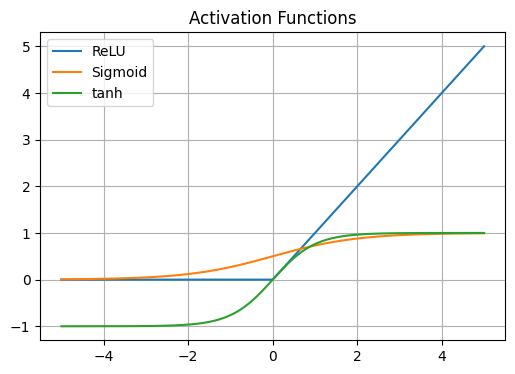

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- Activation functions ---
relu = lambda x: np.maximum(0, x)
sigmoid = lambda x: 1 / (1 + np.exp(-x))
tanh = lambda x: np.tanh(x)

# --- Input domain ---
x = np.linspace(-5, 5, 500)

# --- Plot activation functions ---
plt.figure(figsize=(6,4))
plt.plot(x, relu(x), label="ReLU")
plt.plot(x, sigmoid(x), label="Sigmoid")
plt.plot(x, tanh(x), label="tanh")
plt.title("Activation Functions")
plt.legend()
plt.grid()
plt.show()


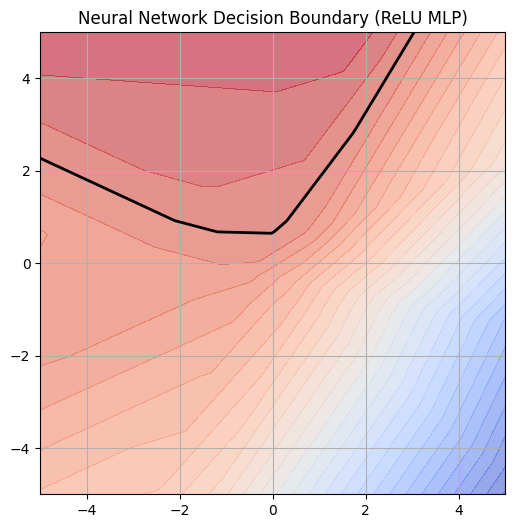

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# --- Activation ---
def relu(x):
    return np.maximum(0, x)

# --- Simple 2D neural network ---
# 2D input -> hidden layer -> output scalar

def neural_net(X, W1, b1, W2, b2):
    """
    X: (N,2)
    W1: (H,2)
    b1: (H,)
    W2: (H,)
    b2: scalar
    """
    H = relu(X @ W1.T + b1)
    return H @ W2 + b2


# --- Grid for decision boundary ---
xx, yy = np.meshgrid(np.linspace(-5, 5, 200),
                     np.linspace(-5, 5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# --- Fixed random network ---
np.random.seed(1)
H = 10

W1 = np.random.randn(H, 2)
b1 = np.random.randn(H)
W2 = 10*np.random.randn(H)
b2 = 0.0

Z = neural_net(grid, W1, b1, W2, b2).reshape(xx.shape)

# --- Plot ---
plt.figure(figsize=(6,6))

# decision regions
plt.contourf(xx, yy, Z, levels=30, cmap="coolwarm", alpha=0.6)
plt.contour(xx, yy, Z, levels=[0], colors="black", linewidths=2)

plt.title("Neural Network Decision Boundary (ReLU MLP)")
plt.grid()
plt.show()

## Cybenko’s Theorem (Universal Approximation Theorem)

> **Theorem (Cybenko, 1989):**  
Let $\sigma:\mathbb{R}\to\mathbb{R}$ be a continuous sigmoidal function, i.e.
$$
\lim_{x \to -\infty} \sigma(x) = 0, \quad \lim_{x \to +\infty} \sigma(x) = 1.
$$

Then finite linear combinations of the form
$$
f_N(x) = \sum_{i=1}^N \alpha_i \sigma(w_i \cdot x + b_i)
$$
are dense in $C([0,1]^d)$ with respect to the uniform norm.

That is:
$$
\forall f \in C([0,1]^d), \ \forall \varepsilon > 0, \ \exists f_N \text{ such that }
\|f - f_N\|_\infty < \varepsilon.
$$

### A Constructive Universal Approximation Theorem (deep ReLU Networks)

The proof of the Cybenko universal approximation theorem relies on deeper tools from measure theory and functional analysis (e.g., the Hahn–Banach theorem and the Fourier transform of measures). It is technically involved and not particularly illuminating from a constructive perspective.

Instead, we present an equally interesting but constructive approximation result: we show that, on the space $C([0,1]^d)$, the class of functions represented by multilayer deep neural networks with ReLU activation is dense.

**Theorem:** Let $f \in C([0,1]^d)$ and let $\varepsilon > 0$. Then there exists a multilayer (deep) neural network with ReLU activation function, such that the function $f_N : [0,1]^d \to \mathbb{R}$ represented by the network satisfies
$$
\|f - f_N\|_{\infty} < \varepsilon.
$$

**Sketch of the proof:**

**Step 1:** approximation with one-dimensional basis functions (hat functions)

Fix $n \in \mathbb{N}$ and define
$$
\phi_k(x) = \max\big(1 - n|x - k/n|,\, 0\big), \quad k=0,\dots,n.
$$

Properties:
- local support,
- partition of unity: $\sum_{k=0}^n \phi_k(x) = 1$,
- piecewise linear
- they can be represented exactly by a two-layer neural network with ReLU activation, since
  $$
  \phi_k(x) = \operatorname{ReLU}\!\big(1 - n\big(\operatorname{ReLU}(x - k/n) + \operatorname{ReLU}(-x + k/n)\big)\big).
  $$

For a multi-index $k=(k_1,\dots,k_d)$, define
$$
\Phi_k(x_1,\dots,x_d)
= \prod_{j=1}^d \phi_{k_j}(x_j).
$$

This is already a product form of one-dimensional functions.

Define the interpolation operator
$$
(I_n f)(x)
= \sum_{k_1,\dots,k_d}
f\!\left(\tfrac{k_1}{n},\dots,\tfrac{k_d}{n}\right)
\prod_{j=1}^d \phi_{k_j}(x_j).
$$

This construction:
- matches $f$ at grid points,
- consists of sums of product functions,
- has the form $\sum_i \prod_j f_{i,j}(x_j)$.

Since $[0,1]^d$ is compact, by Heine's theorem, $f$ is uniformly continuous, hence there exists a modulus of continuity $\omega_f$ such that
$$
|f(x) - f(y)| \le \omega_f(\|x-y\|).
$$

For any $x \in [0,1]^d$, only nearby grid points contribute, and
$$
\|x - k/n\| \le \frac{\sqrt{d}}{n}.
$$

Using that the weights are nonnegative and sum to $1$, we obtain
$$
|f(x) - I_n f(x)|
\le \omega_f\!\left(\tfrac{\sqrt{d}}{n}\right).
$$

Hence,
$$
\|f - I_n f\|_\infty \to 0 \quad \text{as } n \to \infty.
$$

**Step 2:** Reduction of Multiplication to One-Dimensional Approximation

The key observation is the identity
$$
xy = \tfrac{1}{4}\big((x+y)^2 - (x-y)^2\big).
$$

This reduces the problem of approximating the multiplication function $(x,y) \mapsto xy$ to approximating the one-dimensional function $t \mapsto t^2$.

Assume that there exists a ReLU neural network $g : \mathbb{R} \to \mathbb{R}$ such that
$$
|g(t) - t^2| \le \varepsilon \quad \text{for all } t \in [-2,2].
$$

Define
$$
\tilde{m}(x,y)
= \tfrac{1}{4}\big(g(x+y) - g(x-y)\big).
$$

Then $\tilde{m}$ is representable by a neural network, and it satisfies
$$
|\tilde{m}(x,y) - xy| \le C\varepsilon
\quad \text{for all } (x,y) \in [-1,1]^2,
$$
for some absolute constant $C$. Thus, multiplication can be approximated using only a one-dimensional approximation of the square function.

**Step 3:** Iteration of Multiplication
Using the approximate multiplication $\tilde{m}$, we can construct approximations of higher-order products.

For example, for three variables:
$$
x_1 x_2 x_3
\approx \tilde{m}\big(\tilde{m}(x_1,x_2), x_3\big).
$$

More generally, for $k$ variables, define recursively:
$$
M_2(x_1,x_2) = \tilde{m}(x_1,x_2), \quad
M_k(x_1,\dots,x_k) = \tilde{m}\big(M_{k-1}(x_1,\dots,x_{k-1}), x_k\big).
$$

This yields an approximation of the product $x_1 x_2 \cdots x_k$.

The approximation error can be controlled inductively and grows at most linearly with $k$, provided the intermediate values remain in a bounded domain. The resulting construction naturally corresponds to a deeper neural network obtained by composing approximate multipliers.

**Step 4:** Approximation of the Interpolation Operator

In the interpolation operator $I_N f$, the terms
$$
\prod_{j=1}^d \phi_{k_j}(x_j)
$$
appear, where each factor takes values in $[0,1]$. Hence, the product can be approximated using the previously constructed iterative multiplication scheme:
$$
\prod_{j=1}^d \phi_{k_j}(x_j)
\approx M_d\big(\phi_{k_1}(x_1),\ldots,\phi_{k_d}(x_d)\big).
$$

Substituting this approximation into the interpolation formula yields a neural network representation of $I_N f$. Consequently, for every $\varepsilon > 0$, there exists a ReLU deep neural network that approximates $I_N f$ with accuracy $\varepsilon$ in the uniform norm.

> **Theorem (Hornik, 1991):**  
Let $\sigma : \mathbb{R} \to \mathbb{R}$ be a continuous, non-polynomial activation function (either bounded or unbounded). Then the set of functions realized by feedforward neural networks with a single hidden layer and activation $\sigma$ is dense in $C([0,1]^d)$ with respect to the uniform norm.

**Meaning**
- Sigmoid is not special
- ReLU, tanh, and many other activations also yield universality
- Depth is not required for expressivity (but improves efficiency)

### Conceptual summary

| Result | Core idea |
|--------|----------|
| Kolmogorov–Arnold | Multivariate functions reduce to univariate compositions |
| Cybenko | Single hidden layer is dense in $C([0,1]^d)$ |
| Hornik | Universality is robust to activation choice |

Neural networks can be viewed as:
- structured function approximators
- built from ridge functions
- generating dense subalgebras of continuous functions

This provides the theoretical foundation for modern deep learning.

## 4. Refined Approximation Results


### Depth vs. Width Trade-off

Neural networks can be viewed as function classes, where:
- **width** denotes the number of neurons per layer,
- **depth** denotes the number of layers.

Let $\mathcal{F}_{L,W}$ denote the class of functions representable by neural networks of depth $L$ and width at most $W$.

**Key phenomenon:** There exist functions that exhibit a strong separation between depth and width:

- they can be approximated efficiently by **deep neural networks**,
- but require **exponentially many neurons** when represented by shallow networks.

This is not a statement about approximation power (both classes are universal), but about **efficiency of representation**.


#### Informal theorem (depth separation, by Matus Telgarsky, 2016)

There exist functions $f_n : [0,1]^d \to \mathbb{R}$ such that:

- **Deep representation:**
  There exists a ReLU network of depth $O(\log n)$ and size $\mathrm{poly}(n)$ such that
  $$
  \|f_n - N_n^{\text{deep}}\|_\infty \le \varepsilon.
  $$

- **Shallow lower bound:**
  Any ReLU network with a single hidden layer (depth 2) that approximates $f_n$ within comparable accuracy must have width at least
  $$
  \exp(c n)
  $$
  for some constant $c>0$.

##### Typical construction idea

Such separation results are usually based on functions with **hierarchical compositional structure**, for example:

- iterated sawtooth functions,
- recursive folding maps,
- compositions of simple piecewise linear functions,
- binary-tree-like constructions.

A prototypical example is:
$$
f_n(x) = g(g(\cdots g(x)\cdots)),
$$
where the composition depth is $n$.

Deep networks can represent this directly by mirroring the composition structure.

##### Why shallow networks fail

Shallow ReLU networks represent functions of the form
$$
x \mapsto \sum_{i=1}^W a_i \,\max(0, w_i \cdot x + b_i),
$$
which induce a **global piecewise-linear partition** of the input space.

Key limitation:
- each neuron contributes a single hyperplane cut,
- so complexity grows **linearly in width**,
- and cannot efficiently represent repeated composition of local nonlinear transformations.

As a result, the number of linear regions grows only polynomially in $W$.

##### Why deep networks succeed

Deep networks construct functions via composition:
$$
x \mapsto f_L \circ f_{L-1} \circ \cdots \circ f_1(x),
$$
where each layer transforms and reuses intermediate features.

This leads to:

- **exponential growth of linear regions in depth**,
- reuse of intermediate representations,
- hierarchical feature construction.

Thus, depth acts as a mechanism for **exponential expressivity gain**.

#### Conceptual takeaway

Depth does not increase what can be represented in principle, but it drastically changes:

- the **complexity of representation**
- the **efficiency of approximation**
- the **inductive bias toward compositional structure**

### Barron Class

The Barron class consists of functions whose Fourier transform has finite first moment.

Formally, a function $f : [0,1]^d \to \mathbb{R}$ belongs to the Barron class if its Fourier transform $\hat{f}$ satisfies:
$$
\int_{\mathbb{R}^d} \|\omega\| \, |\hat{f}(\omega)| \, d\omega < \infty.
$$

Functions in the Barron class admit efficient approximation by **two-layer neural networks**:

- width grows only polynomially in $1/\varepsilon$
- approximation error scales as $O(1/\sqrt{N})$ with $N$ neurons

This makes them a natural class for studying shallow network efficiency.

- The Barron class captures functions well-approximated by **shallow networks**
- Telgarsky’s construction shows that there exist functions outside this regime where:
  - depth provides exponential efficiency gains
  - shallow networks fail due to lack of compositional structure

## 5. Important Neural Network Architectures

This section summarizes the most important neural network architectures from both a practical and mathematical viewpoint, focusing on their structural bias and approximation properties.

---

### Feedforward Networks (MLP)

A multilayer perceptron (MLP) is a composition of affine maps and nonlinearities:
$$
f(x) = W_L \sigma(W_{L-1} \dots \sigma(W_1 x + b_1)\dots) + b_L.
$$

Key properties:
- Fully connected layers
- No explicit structure on input domain
- Universal approximator (Cybenko, Hornik)

Limitations:
- ignore spatial or temporal structure
- parameter inefficient in high-dimensional structured data

---

### Convolutional Neural Networks (CNN)

A convolutional layer computes:
$$
(f * k)(x) = \sum_{u} f(x-u)\,k(u)
$$

followed by nonlinear activation.


#### Equivariance property

Let $T_a$ be translation:
$$
T_a f(x) = f(x-a).
$$

Then convolution satisfies:
$$
T_a(f * k) = (T_a f) * k.
$$

CNNs impose a **group invariance bias**:
- reduce effective hypothesis space
- encode prior knowledge about spatial structure

#### Approximation role

- better sample efficiency than MLPs
- especially effective for images and signals

---

### Recurrent Neural Networks (RNN)

A recurrent network evolves via:
$$
h_t = \sigma(W_h h_{t-1} + W_x x_t + b).
$$

Output:
$$
y_t = g(h_t).
$$

RNNs define a nonlinear dynamical system:
- state $h_t$
- driven by input sequence $(x_t)$

An RNN is a **parameterized nonlinear state-space model**.

It approximates:
- sequence-to-sequence maps
- dynamical system observers

Issues:
- vanishing/exploding gradients
- limited long-term memory

Variants:
- LSTM (gated memory)
- GRU (simplified gating)

---

### Transformer Architecture

**Core idea: attention mechanism**

Given input embeddings:
- queries $Q$
- keys $K$
- values $V$

attention is defined as:
$$
\mathrm{Att}(Q,K,V)
=
\mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d}}\right)V.
$$

Each token:
- compares itself to all others (via dot products)
- forms a weighted average of information

Transformers implement:
- permutation-aware feature mixing
- learned kernel smoothing

They can be interpreted as:
- adaptive kernel machines
- data-dependent integral operators

- global receptive field (unlike CNNs)
- highly parallelizable
- scale well with data size

Transformers can simulate:
- Turing-complete computation (with positional encoding)
- arbitrary sequence transformations under sufficient width/depth

### Comparison of Architectures

| Architecture | Inductive bias | Strength | Weakness |
|-------------|---------------|----------|----------|
| MLP | none | universal approximation | inefficient on structured data |
| CNN | locality + translation equivariance | image/signal efficiency | limited global context |
| RNN | temporal recurrence | sequence modeling | long-range dependency issues |
| Transformer | global attention | scalable + expressive | data-hungry |